In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt


sys.path.append("../")

In [2]:
DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
PLOTS_DIR = "../plots"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_with_layer_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_with_layer_mppc_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_pixel_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_with_layer_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_with_layer_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_with_layer_mppc_spacetime.npy"

sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)

In [3]:
sig_only_pixel_time = sig_only_pixel_spacetime[:,:, -1]
sig_only_mppc_time = sig_only_mppc_spacetime[:,:, -1]
sig_pixel_time = sig_pixel_spacetime[:,:, -1]
sig_mppc_time = sig_mppc_spacetime[:,:, -1]
background_pixel_time = bg_pixel_spacetime[:,:, -1]
background_mppc_time = bg_mppc_spacetime[:,:, -1]

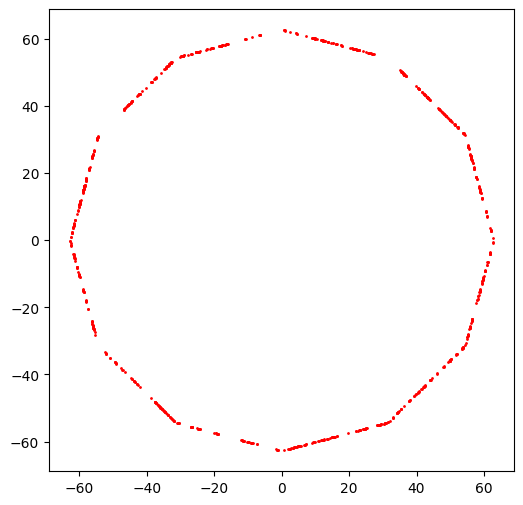

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
#ax.scatter(bg_pixel_spacetime[:1000,:10, 0], bg_pixel_spacetime[:1000,:10, 1], s=1, color="blue", label="Pixel")
ax.scatter(bg_mppc_spacetime[:100,:10, 0], bg_mppc_spacetime[:100,:10, 1], s=1, color="red", label="MPPC")

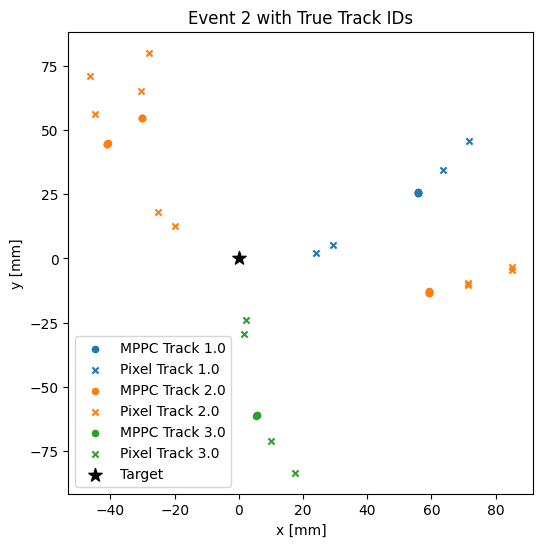

In [5]:
event_index = 2
colors = plt.get_cmap("tab10", 10)
fig, ax = plt.subplots(figsize=(6, 6))
mppc_track_ids = sig_only_mppc_spacetime[event_index, :, 4]
pixel_track_ids = sig_only_pixel_spacetime[event_index, :, 4]
color_iter = 0
for track_id in np.unique(np.concat([pixel_track_ids, mppc_track_ids])):
    if track_id <= 0:
        continue
    mask_track_mask = mppc_track_ids == track_id
    pix_track_mask = pixel_track_ids == track_id
    color=colors(color_iter)
    ax.scatter(sig_only_mppc_spacetime[event_index, mask_track_mask, 0],
               sig_only_mppc_spacetime[event_index, mask_track_mask, 1],
               s=20, color=color,marker="o", label=f"MPPC Track {track_id}")
    ax.scatter(sig_only_pixel_spacetime[event_index, pix_track_mask, 0],
               sig_only_pixel_spacetime[event_index, pix_track_mask, 1],
               s=20, color=color, marker="x", label=f"Pixel Track {track_id}")
    color_iter += 1
ax.scatter([0], [0], s=100, color="black", marker="*", label="Target")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title(f"Event {event_index} with True Track IDs")
ax.legend(loc="best")

In [6]:
import numpy as np

def count_edges_per_event(pixel, mppc):
    # mask valid hits
    num_mppc_hits = (mppc[..., -1] != -1).sum(axis=-1)
    num_pixel_hits = (pixel[..., -1] != -1).sum(axis=-1)
    total_hits = num_mppc_hits + num_pixel_hits
    return total_hits * (total_hits - 1) // 2


def count_time_filtered_edges(pixel, mppc):
    num_events = pixel.shape[0]
    num_edges_per_event = np.zeros(num_events, dtype=int)

    for i in range(num_events):
        # valid pixel times
        pix_times = pixel[i, :, -1]
        pix_times = pix_times[pix_times != -1]

        if pix_times.size == 0:
            continue

        # if times are effectively ints, cast
        if np.allclose(pix_times, np.round(pix_times)):
            pix_times = pix_times.astype(int)
            unique_times, pix_counts = np.unique(pix_times, return_counts=True)
        else:
            # fallback for true floats
            unique_times, pix_counts = np.unique(pix_times, return_counts=True)

        # align mppc times modulo 8
        mppc_times = mppc[i, :, -1]
        mppc_hits = (mppc_times[:, None] % 8 == unique_times[None, :] % 8).sum(axis=0)

        total_counts = pix_counts + mppc_hits
        num_edges_per_event[i] = np.sum(total_counts * (total_counts - 1) // 2)

    return num_edges_per_event

def count_layer_filtered_edges(pixel, mppc):
    # vectorized per-event counts
    pixel_layers = [np.sum(pixel[:, :, 3] == l, axis=1) for l in range(1, 5)]
    mppc_edges = np.sum(mppc[:, :, 3] != -1, axis=1)

    l1, l2, l3, l4 = pixel_layers
    num_edges_per_event = (
        l1 * l2
        + l2 * mppc_edges
        + mppc_edges * l3
        + l3 * l4
        + l1 * (l1 - 1) // 2
        + l2 * (l2 - 1) // 2
        + l3 * (l3 - 1) // 2
        + l4 * (l4 - 1) // 2
    )
    return num_edges_per_event


def count_layer_time_filtered_edges(pixel, mppc):
    num_events = pixel.shape[0]
    num_edges_per_event = np.zeros(num_events, dtype=int)

    for i in range(num_events):
        pix_times = pixel[i, :, -1]
        pix_times = np.unique(pix_times[pix_times != -1])

        if pix_times.size == 0:
            continue

        for t in pix_times:
            mask = pixel[i, :, -1] == t
            layers = pixel[i, mask, 3]

            # counts per layer
            l1 = np.sum(layers == 1)
            l2 = np.sum(layers == 2)
            l3 = np.sum(layers == 3)
            l4 = np.sum(layers == 4)

            # mppc hits modulo 8
            mppc_hits = np.sum(mppc[i, mask, -1] % 8 == t % 8)

            # mppc self edges if time diff < 0.1
            num_edges_per_event[i] += (
                l1 * l2
                + l2 * mppc_hits
                + mppc_hits * l3
                + l3 * l4
                + l1 * (l1 - 1) // 2
                + l2 * (l2 - 1) // 2
                + l3 * (l3 - 1) // 2
                + l4 * (l4 - 1) // 2
            )
    return num_edges_per_event


In [7]:
signal_fully_connected_edges = count_edges_per_event(sig_pixel_spacetime, sig_mppc_spacetime)
background_fully_connected_edges = count_edges_per_event(bg_pixel_spacetime, bg_mppc_spacetime)
signal_only_fully_connected_edges = count_edges_per_event(sig_only_pixel_spacetime, sig_only_mppc_spacetime)
signal_time_filtered_edges = count_time_filtered_edges(sig_pixel_spacetime, sig_mppc_spacetime)
background_time_filtered_edges = count_time_filtered_edges(bg_pixel_spacetime, bg_mppc_spacetime)
signal_only_time_filtered_edges = count_time_filtered_edges(sig_only_pixel_spacetime, sig_only_mppc_spacetime)
signal_layer_filtered_edges = count_layer_filtered_edges(sig_pixel_spacetime, sig_mppc_spacetime)
background_layer_filtered_edges = count_layer_filtered_edges(bg_pixel_spacetime, bg_mppc_spacetime)
signal_only_layer_filtered_edges = count_layer_filtered_edges(sig_only_pixel_spacetime, sig_only_mppc_spacetime)
signal_time_layer_filtered_edges = count_layer_time_filtered_edges(sig_pixel_spacetime, sig_mppc_spacetime)
background_time_layer_filtered_edges = count_layer_time_filtered_edges(bg_pixel_spacetime, bg_mppc_spacetime)
signal_only_time_layer_filtered_edges = count_layer_time_filtered_edges(sig_only_pixel_spacetime, sig_only_mppc_spacetime)

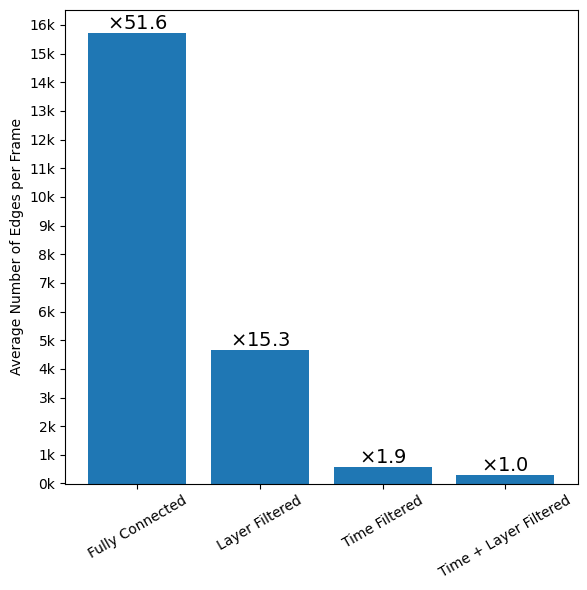

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(1 * 6, 6))
edge_count = np.array([background_fully_connected_edges.mean(), background_layer_filtered_edges.mean(), background_time_filtered_edges.mean(), background_time_layer_filtered_edges.mean()])
ax = [ax]
ax[0].bar(np.arange(4), edge_count)
ax[0].set_ylabel('Average Number of Edges per Frame')
#ax[0].set_title('Background Frames')
ax[0].set_xticks(np.arange(4))
ax[0].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=1000)
ax[0].set_yticks(y_ticks)
ax[0].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])


# Annotate each bar with the difference to the time+layer filtered version
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[0].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)

edge_count = np.array([signal_fully_connected_edges.mean(), signal_layer_filtered_edges.mean(), signal_time_filtered_edges.mean(), signal_time_layer_filtered_edges.mean()])
if len(ax) > 1:
    ax[1].bar(np.arange(4), edge_count, color='orange')
    ax[1].set_ylabel('Average Number of Edges per Frame')
    ax[1].set_title('Signal Frames')
    ax[1].set_xticks(np.arange(4))
    ax[1].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
    for i in range(4):
        factor = edge_count[i] / edge_count[3]
        ax[1].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
    ax[1].set_yticks(np.arange(0, np.ceil(np.max(edge_count) + 500), step=1000))
    y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=1000)
    ax[1].set_yticks(y_ticks)
    ax[1].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])
if len(ax) > 2:
    edge_count = np.array([signal_only_fully_connected_edges.mean(), signal_only_layer_filtered_edges.mean(), signal_only_time_filtered_edges.mean(), signal_only_time_layer_filtered_edges.mean()])
    ax[2].bar(np.arange(4), edge_count, color='green')
    ax[2].set_ylabel('Average Number of Edges per Frame')
    ax[2].set_title('Signal Only Frames')
    ax[2].set_xticks(np.arange(4))
    ax[2].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
    for i in range(4):
        factor = edge_count[i] / edge_count[3]
        ax[2].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
    y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=500)
    ax[2].set_yticks(y_ticks)
    ax[2].set_yticklabels([f"{float(y/1000):.1f}k" for y in y_ticks])

fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/edge_count_comparison.png")


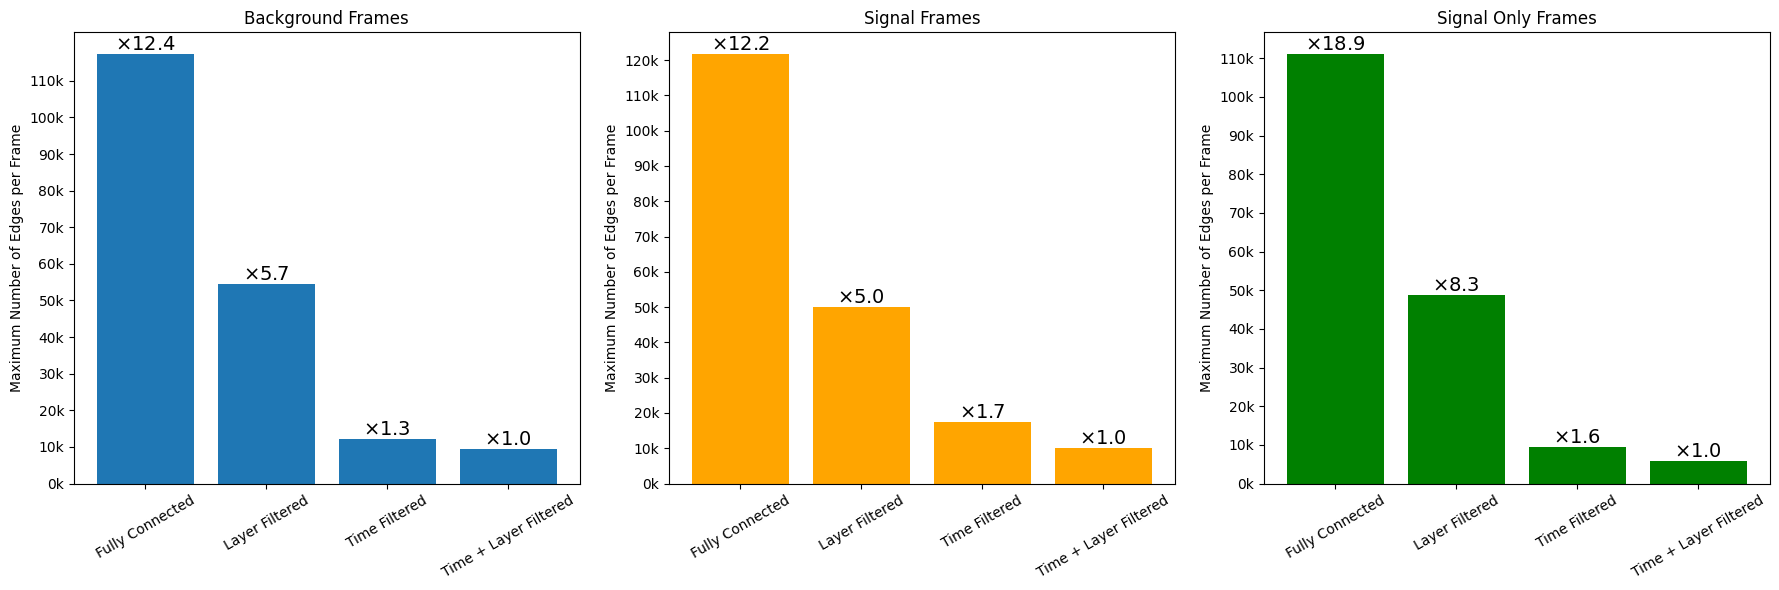

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
edge_count = np.array([background_fully_connected_edges.max(), background_layer_filtered_edges.max(), background_time_filtered_edges.max(), background_time_layer_filtered_edges.max()])
ax[0].bar(np.arange(4), edge_count)
ax[0].set_ylabel('Maximum Number of Edges per Frame')
ax[0].set_title('Background Frames')
ax[0].set_xticks(np.arange(4))
ax[0].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=10000)
ax[0].set_yticks(y_ticks)
ax[0].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])


# Annotate each bar with the difference to the time+layer filtered version
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[0].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)

edge_count = np.array([signal_fully_connected_edges.max(), signal_layer_filtered_edges.max(), signal_time_filtered_edges.max(), signal_time_layer_filtered_edges.max()])
ax[1].bar(np.arange(4), edge_count, color='orange')
ax[1].set_ylabel('Maximum Number of Edges per Frame')
ax[1].set_title('Signal Frames')
ax[1].set_xticks(np.arange(4))
ax[1].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[1].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
ax[1].set_yticks(np.arange(0, np.ceil(np.max(edge_count) + 500), step=1000))
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=10000)
ax[1].set_yticks(y_ticks)
ax[1].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])

edge_count = np.array([signal_only_fully_connected_edges.max(), signal_only_layer_filtered_edges.max(), signal_only_time_filtered_edges.max(), signal_only_time_layer_filtered_edges.max()])
ax[2].bar(np.arange(4), edge_count, color='green')
ax[2].set_ylabel('Maximum Number of Edges per Frame')
ax[2].set_title('Signal Only Frames')
ax[2].set_xticks(np.arange(4))
ax[2].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[2].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=10000)
ax[2].set_yticks(y_ticks)
ax[2].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])

plt.tight_layout()
plt.show()

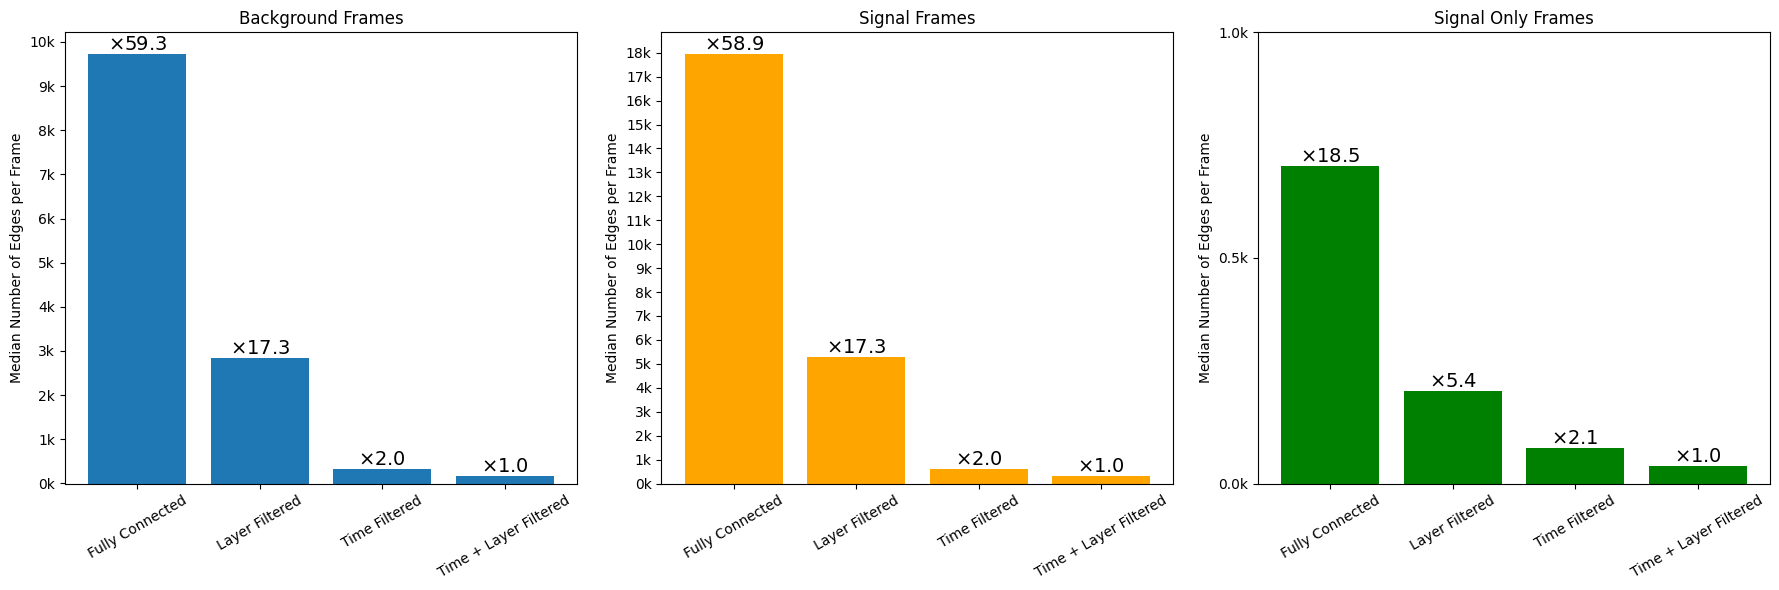

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
edge_count = np.array([np.median(background_fully_connected_edges), np.median(background_layer_filtered_edges), np.median(background_time_filtered_edges), np.median(background_time_layer_filtered_edges)])
ax[0].bar(np.arange(4), edge_count)
ax[0].set_ylabel('Median Number of Edges per Frame')
ax[0].set_title('Background Frames')
ax[0].set_xticks(np.arange(4))
ax[0].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=1000)
ax[0].set_yticks(y_ticks)
ax[0].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])


# Annotate each bar with the difference to the time+layer filtered version
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[0].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)

edge_count = np.array([np.median(signal_fully_connected_edges), np.median(signal_layer_filtered_edges), np.median(signal_time_filtered_edges), np.median(signal_time_layer_filtered_edges)])
ax[1].bar(np.arange(4), edge_count, color='orange')
ax[1].set_ylabel('Median Number of Edges per Frame')
ax[1].set_title('Signal Frames')
ax[1].set_xticks(np.arange(4))
ax[1].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[1].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
y_ticks = np.arange(1, np.ceil(np.max(edge_count) + 500), step=1000)
ax[1].set_yticks(y_ticks)
ax[1].set_yticklabels([f"{int(y/1000)}k" for y in y_ticks])

edge_count = np.array([np.median(signal_only_fully_connected_edges), np.median(signal_only_layer_filtered_edges), np.median(signal_only_time_filtered_edges), np.median(signal_only_time_layer_filtered_edges)])
ax[2].bar(np.arange(4), edge_count, color='green')
ax[2].set_ylabel('Median Number of Edges per Frame')
ax[2].set_title('Signal Only Frames')
ax[2].set_xticks(np.arange(4))
ax[2].set_xticklabels(['Fully Connected', 'Layer Filtered', 'Time Filtered', 'Time + Layer Filtered'], rotation=30)
for i in range(4):
    factor = edge_count[i] / edge_count[3]
    ax[2].text(i, edge_count[i], r"$\times$" + f"{factor:.1f}", ha='center', va='bottom', fontsize=14)
y_ticks = np.arange(0, np.ceil(np.max(edge_count) + 500), step=500)
ax[2].set_yticks(y_ticks)
ax[2].set_yticklabels([f"{float(y/1000)}k" for y in y_ticks])

plt.tight_layout()
plt.show()